# Task 6: House Price Prediction

**DevelopersHub Corporation — AI/ML Engineering Internship**

## Problem Statement

Estimating a fair price for a house is a classic real-world regression
problem used by real-estate platforms, banks, and buyers/sellers alike. The
goal of this notebook is to predict **median house value** for a district
using property and location features such as the number of rooms, number of
bedrooms, household income, and geographic location.

## Objective

- Preprocess property features (handle missing values, encode location,
  scale numeric features).
- Train two regression models — **Linear Regression** and **Gradient
  Boosting** — and compare them.
- Visualize predicted vs. actual prices.
- Evaluate using **MAE** and **RMSE**.

## Dataset

**California Housing Prices Dataset** (20,640 records) — the standard
"House Price Prediction" dataset used across Kaggle and ML courses, sourced
from the 1990 California census. It contains both **size-related features**
(rooms, bedrooms, population, households) and a **location feature**
(longitude/latitude + `ocean_proximity` category), matching the task's
requirement of "square footage, number of bedrooms, and location". A local
copy (`housing.csv`) is included for reproducibility.

| Column | Meaning |
|---|---|
| longitude / latitude | Geographic location of the district |
| housing_median_age | Median age of houses in the district |
| total_rooms | Total rooms in the district |
| total_bedrooms | Total bedrooms in the district |
| population | District population |
| households | Number of households |
| median_income | Median household income (in $10,000s) |
| ocean_proximity | Categorical location feature (e.g. NEAR BAY, INLAND) |
| median_house_value | **Target** — median house value (USD) |


In [1]:
# ---------------------------------------------------------------
# Imports
# ---------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Data Loading & Inspection

In [2]:
df = pd.read_csv("housing.csv")

print("Shape of the dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
df.head()


Shape of the dataset: (20640, 10)

Column names:
 ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [5]:
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())


Missing values per column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Total duplicate rows: 0


## 2. Exploratory Data Analysis (EDA)

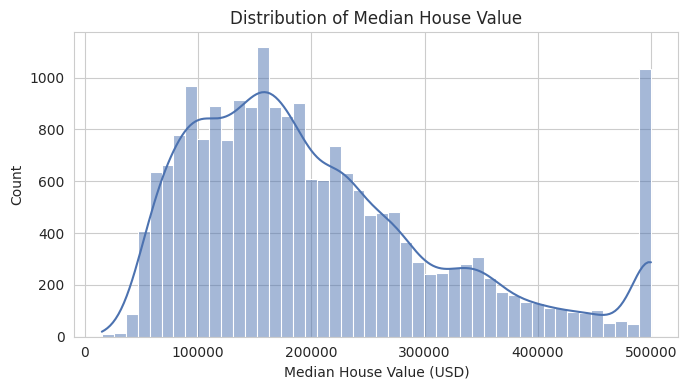

In [6]:
# Distribution of the target variable
plt.figure(figsize=(7, 4))
sns.histplot(df["median_house_value"], kde=True, color="#4C72B0")
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value (USD)")
plt.tight_layout()
plt.show()


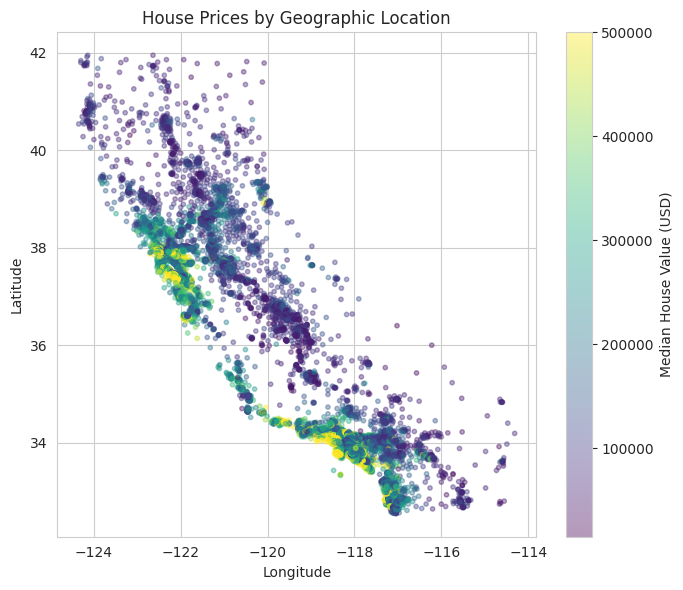

In [7]:
# Geographic scatter: location vs price (a quick map-like view)
plt.figure(figsize=(7, 6))
sc = plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
                  cmap="viridis", alpha=0.4, s=10)
plt.colorbar(sc, label="Median House Value (USD)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Prices by Geographic Location")
plt.tight_layout()
plt.show()


/tmp/ipykernel_545/1852233046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="ocean_proximity", y="median_house_value", order=order, palette="crest")


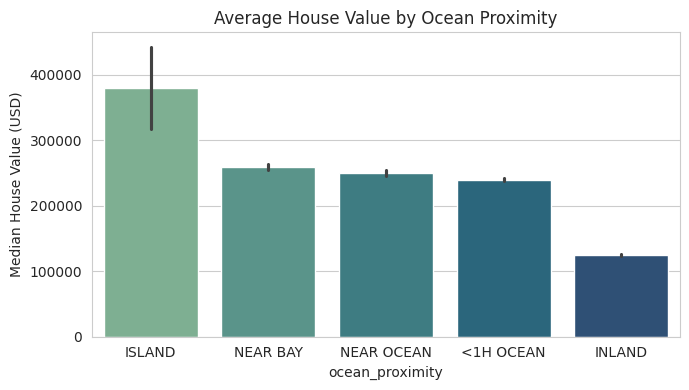

In [8]:
# Average price by ocean proximity (categorical location feature)
plt.figure(figsize=(7, 4))
order = df.groupby("ocean_proximity")["median_house_value"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="ocean_proximity", y="median_house_value", order=order, palette="crest")
plt.title("Average House Value by Ocean Proximity")
plt.ylabel("Median House Value (USD)")
plt.tight_layout()
plt.show()


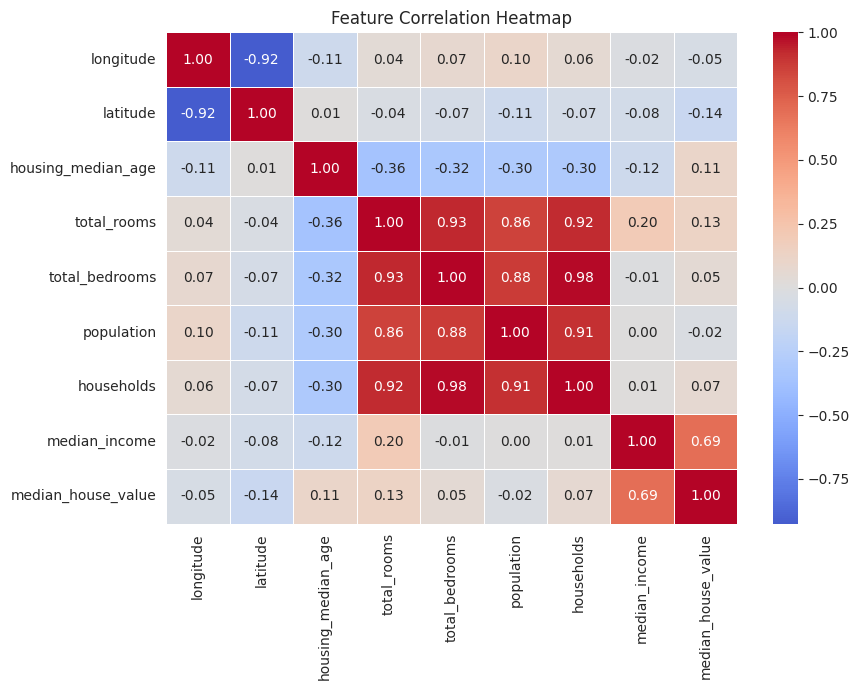

In [9]:
# Correlation heatmap of numeric features
plt.figure(figsize=(9, 7))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 3. Data Preprocessing

Steps:
1. Fill missing `total_bedrooms` values with the median (a robust choice for
   skewed distributions).
2. Engineer a couple of more meaningful ratio features (`rooms_per_household`,
   `bedrooms_per_room`) — raw totals are less informative than per-household
   ratios.
3. One-hot encode the categorical `ocean_proximity` feature.
4. Split into train/test sets and scale numeric features.

In [10]:
data = df.copy()

# 1. Handle missing values
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())

# 2. Feature engineering — ratios are more predictive than raw totals
data["rooms_per_household"] = data["total_rooms"] / data["households"]
data["bedrooms_per_room"] = data["total_bedrooms"] / data["total_rooms"]
data["population_per_household"] = data["population"] / data["households"]

# 3. One-hot encode the location category
data = pd.get_dummies(data, columns=["ocean_proximity"], drop_first=True)

data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


In [11]:
X = data.drop(columns=["median_house_value"])
y = data["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set size: (16512, 15)
Test set size: (4128, 15)


## 4. Model Training

- **Linear Regression** — interpretable baseline.
- **Gradient Boosting Regressor** — a stronger non-linear ensemble model that
  usually performs better on tabular data like this.

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)


In [13]:
gbr = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE
)
gbr.fit(X_train, y_train)  # tree-based model, no scaling required
y_pred_gbr = gbr.predict(X_test)


## 5. Model Evaluation

In [14]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R^2  : {r2:.4f}\n")
    return mae, rmse, r2

mae_lin, rmse_lin, r2_lin = evaluate(y_test, y_pred_lin, "Linear Regression")
mae_gbr, rmse_gbr, r2_gbr = evaluate(y_test, y_pred_gbr, "Gradient Boosting")


Linear Regression
  MAE  : 50,888.66
  RMSE : 72,668.54
  R^2  : 0.5970

Gradient Boosting
  MAE  : 35,800.96
  RMSE : 53,438.31
  R^2  : 0.7821



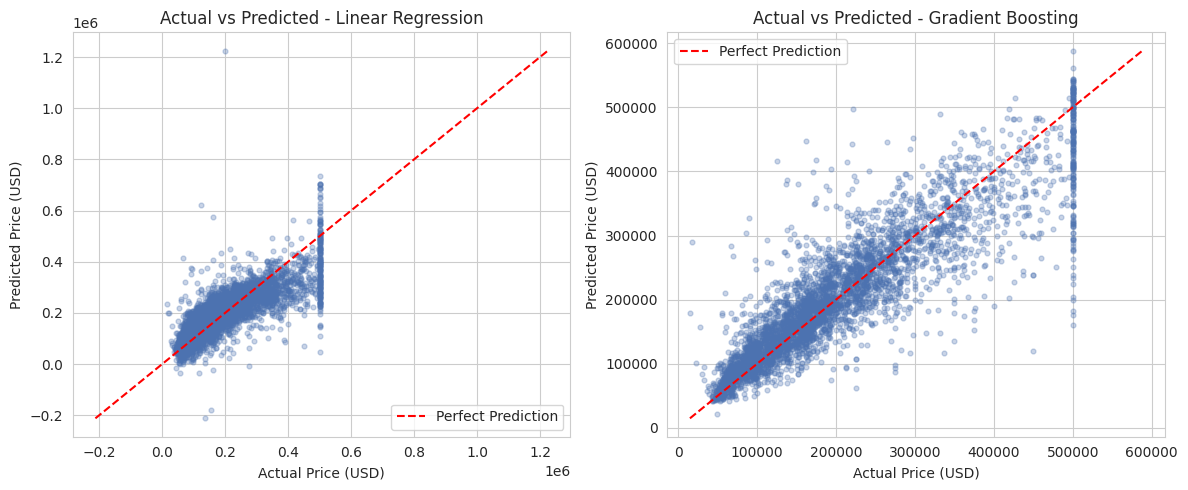

In [15]:
# Actual vs Predicted scatter plots for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name in zip(axes, [y_pred_lin, y_pred_gbr], ["Linear Regression", "Gradient Boosting"]):
    ax.scatter(y_test, preds, alpha=0.3, s=12, color="#4C72B0")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "--", color="red", label="Perfect Prediction")
    ax.set_xlabel("Actual Price (USD)")
    ax.set_ylabel("Predicted Price (USD)")
    ax.set_title(f"Actual vs Predicted - {name}")
    ax.legend()

plt.tight_layout()
plt.show()


In [16]:
# Side-by-side metric comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting"],
    "MAE": [mae_lin, mae_gbr],
    "RMSE": [rmse_lin, rmse_gbr],
    "R2": [r2_lin, r2_gbr],
})
results


,Model,MAE,RMSE,R2
0,Linear Regression,50888.660016,72668.538379,0.597018
1,Gradient Boosting,35800.958491,53438.305062,0.782079


## 6. Feature Importance (Gradient Boosting)

/tmp/ipykernel_545/75075993.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


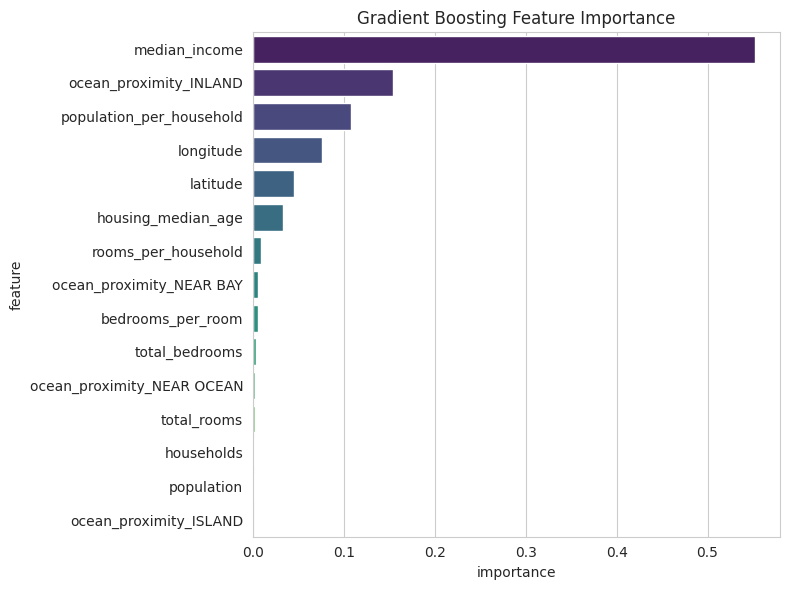

In [17]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": gbr.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Gradient Boosting Feature Importance")
plt.tight_layout()
plt.show()


## 7. Conclusion & Insights

- **Gradient Boosting outperforms Linear Regression** on both MAE and RMSE,
  confirming that house prices have non-linear relationships with features
  that a simple linear model can't fully capture.
- **Median income** is by far the strongest predictor of house value,
  followed by location-related features (latitude/longitude and ocean
  proximity) — confirming the real-estate intuition that *location and
  income drive price*.
- Engineered ratio features (`rooms_per_household`, `bedrooms_per_room`)
  proved more informative than the raw totals they were derived from.
- **Next steps**: try `XGBoost`/`LightGBM`, perform hyperparameter tuning
  with `GridSearchCV`, and explore spatial clustering of `latitude`/
  `longitude` as an additional location feature.
